# Using RandomForestRegressor to Predict Abalone Snail Ages

In this notebook, we use a random forest regressor to predict the ages of abalone snails using their physical measurements as predictor variables. The [Abalone dataset](https://archive.ics.uci.edu/dataset/1/abalone) comes from UC Irvine's Machine Learning Repository.

Abalones are marine snails harvested along the California coastline. According to the dataset information summary, determining their age traditionally requires cutting the shell, staining it, and counting the number of rings under a microscope. This process is tedious and harmful to the snails, as their shells are part of their bodies and vital for their protection.

The Abalone dataset contains physical measurements (length, diameter, height, and several weights) collected on 4,177 snails, along with their ring count, which is a direct proxy for age (approximate age = rings + 1.5 years).

The goal here is to train a random forest regressor model to predict the number of rings from the continuous physical features. If our model is fits well, this could replace what would otherwise be a labour-intensive measurement task.

**Features (after one-hot encoding the sex variable):**
| **Feature** | **Type** | **Description** |
|---|---|---|
| Length | Continuous | Longest shell measurement (mm) |
| Diameter | Continuous | Perpendicular to length (mm) |
| Height | Continuous | Height with meat in shell (mm) |
| Whole weight | Continuous | Whole abalone weight (g) |
| Shucked weight | Continuous | Weight of meat (g) |
| Viscera weight | Continuous | Gut weight after bleeding (g) |
| Shell weight | Continuous | Shell weight after being dried (g) |
| Sex_F / Sex_I / Sex_M | Categorical | One-hot encoded sex (female, infant, male) |

**Target:** Rings (integer, 1–29)

---

## Load and Explore Data

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ml_package import (
    RandomForestRegressor,
    LinearRegression,
    StandardScaler,
    train_test_split,
    randomized_search_cv,
    k_fold_split,
    regression_metrics,
)

np.random.seed(42)

In [15]:
# Load in data
df = pd.read_csv("abalone.data", header = None)

# Name columns
columns = [
    "Sex", "Length", "Diameter", "Height", "WholeWeight",
    "ShuckedWeight", "VisceraWeight", "ShellWeight", "Rings"
]

df = pd.read_csv("abalone.data", names=columns)

df.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [16]:
# Assign features and target
X = df.drop(columns=['Rings'])
y = df["Rings"]

# Descriptive statistics
print(f"\nTarget (Rings)  —  mean: {y.mean():.2f}, std: {y.std():.2f}, range: [{y.min()}, {y.max()}]")
X.describe().round(3)


Target (Rings)  —  mean: 9.93, std: 3.22, range: [1, 29]


,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight
count,4177.000,4177.000,4177.000,4177.000,4177.000,4177.000,4177.000
mean,0.524,0.408,0.140,0.829,0.359,0.181,0.239
std,0.120,0.099,0.042,0.490,0.222,0.110,0.139
min,0.075,0.055,0.000,0.002,0.001,0.000,0.002
25%,0.450,0.350,0.115,0.442,0.186,0.094,0.130
50%,0.545,0.425,0.140,0.800,0.336,0.171,0.234
75%,0.615,0.480,0.165,1.153,0.502,0.253,0.329
max,0.815,0.650,1.130,2.826,1.488,0.760,1.005


In [17]:
# One-hot encode the Sex categorical feature
X_enc = pd.get_dummies(X, columns=["Sex"], drop_first=False).astype(float)
feat_names = list(X_enc.columns)
X_arr = X_enc.values

---

Below, we create a histogram showing the distribution of the target variable (number of rings) and a heatmap displaying the correlations between features.

---

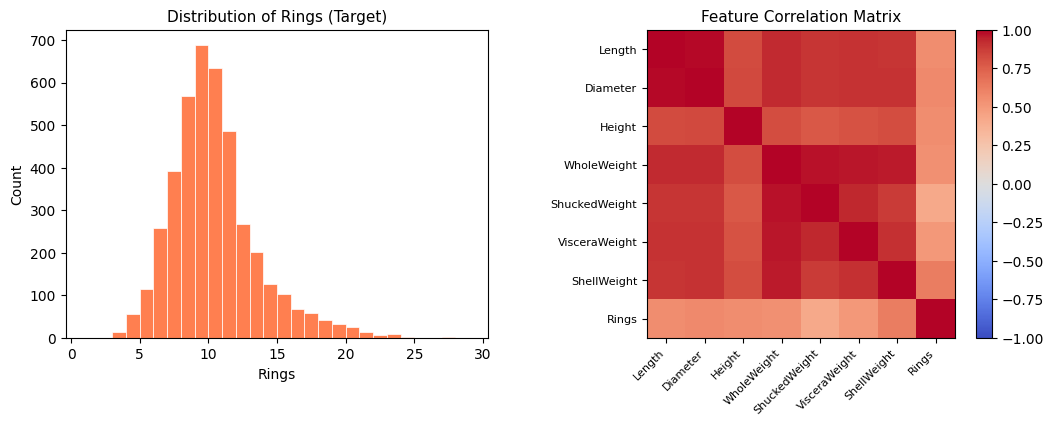


Correlation with Rings:
ShellWeight      0.628
Diameter         0.575
Height           0.557
Length           0.557
WholeWeight      0.540
VisceraWeight    0.504
ShuckedWeight    0.421


In [18]:
# Rings distribution + correlation heat-map
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Rings histogram
ax1.hist(y, bins=28, color = "coral", edgecolor="white", linewidth=0.5)
ax1.set_title("Distribution of Rings (Target)", fontsize=11)
ax1.set_xlabel("Rings"); ax1.set_ylabel("Count")

# Correlation matrix
X_numeric = X.select_dtypes(include=[np.number]).copy()
X_numeric["Rings"] = y
corr = X_numeric.corr()
im = ax2.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr))); ax2.set_yticks(range(len(corr)))
ax2.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_title("Feature Correlation Matrix", fontsize=11)

plt.show()
print("\nCorrelation with Rings:")
print(corr["Rings"].drop("Rings").sort_values(ascending=False).round(3).to_string())

---

The correlation heatmap shows that shell weight and diameter correlate most strongly with the number of rings (about 0.63 and 0.58, respectively), implying that these may be the most informative predictors for our model. 

The heatmap also shows that the four weight features are highly intercorrelated, suggesting that there is multicollinearity present in our feature data. This is typically a problem for linear regression, as the redundant information may inflate coefficient variances. However, random forest regressors are more robust to multicollinearity because they only choose one feature to split on at each node (rather than trying to fit a model to all equations at once) and because each tree is trained on a subset of the total features.

---

## Linear Regression Baseline

We now train a linear regression model to the abalone data to use for comparison with our random forest fit. For linear regression, we standardize the data so to ensure that all features have comparable gradient magnitudes, preventing a single large-scale feature from dominating the weight updates. Note that standardizing the data is not required for the random forest fit.

---


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)

# Random Forest is scale-invariant, but we scale for fair baseline comparison
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")


Train: 3341  |  Test: 836


In [20]:
lr = LinearRegression()
lr.train(X_train_s, y_train, eta=0.01, epochs=2000)
y_pred_lr = lr.predict(X_test_s)

r2_lr   = regression_metrics.r_squared(y_test, y_pred_lr)
rmse_lr = regression_metrics.rmse(y_test, y_pred_lr)
print(f"Linear Regression — R²: {r2_lr:.4f}   RMSE: {rmse_lr:.4f} rings")

Linear Regression — R²: 0.4944   RMSE: 2.3257 rings


---

Our linear regression model returned an R-squared value of 0.49, which implies that 49% of the total variation in the number of ring rings can be explained by the feature data.

---

## Randomized Search and Random Forest Fit

We define distributions for four hyperparameters and let `randomized_search_cv` sample and evaluate 30 random combinations via 5-fold cross-validation. The scoring method is `score`, which calls `RandomForestRegressor.score(X_val, y_val)`. This returns R-squared on the validation fold, so the higher the better.

**Parameters searched:**
| Parameter | Distribution | Meaning |
|---|---|---|
| `n_estimators` | {50, 250, 350} | Number of trees in the forest |
| `max_depth` | {5, 7, 10} | Maximum depth of each tree |
| `min_samples_split` | {2, 4} | Min samples needed to attempt a node split |
| `max_features` | {2, 3, 5, None} | Features considered at each split (None = floor(n/3)) |

One thing I must note is that the `randomized_search_cv` method in this package takes a little while to run. Thus, I decided not to search over too many parameters in the randomized search. Also, I only iterated the randomized search once, rather than the default 10 times. However, I compared the results from this search to a search over a larger parameter grid using SK-Learn's `RandomizedSearchCV`. The best parameters from this search, along with the results, are commented out for reference. The larger parameter grid produced a very similar R-squared value, suggesting that the search using our `randomized_search_cv` was fine. 

For convenience, I listed the best parameters returned from the randomized search using `randomized_search_cv`, so you do not have to run it yourself.

---

In [ ]:
#Define grid of hyperparameters to tune over with our RandomForestRegressor class
param_distributions = {
    "n_estimators":     [100, 250, 350],
    "max_depth":        [5, 7, 10],
    "min_samples_split":[2, 4],
    "max_features":     [2, 3, 5, None],
}

In [ ]:
# Run the randomized search
search_results = randomized_search_cv(
    estimator = RandomForestRegressor,
    param_distributions = param_distributions,
    X = X_train,
    y = y_train,
    n_iter = 1,
    n_splits = 5,
    scoring = "score",    
    fit_method = "fit",
    random_state = 42,
    refit = True,          
)


print(f"Best CV R-squared  : {search_results['best_score']:.4f}")
print(f"Best params : {search_results['best_params']}")

Best CV R-squared  : 0.5542
Best params : {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 4, 'max_features': 3}


In [44]:
best_model = RandomForestRegressor(n_estimators = 100, max_depth = 10, 
                                   min_samples_split = 4, max_features = 3, random_state=42)
best_model.fit(X_train, y_train)
y_pred_rf = best_model.predict(X_test)

r2_rf   = regression_metrics.r_squared(y_test, y_pred_rf)
rmse_rf = regression_metrics.rmse(y_test, y_pred_rf)
mae_rf  = regression_metrics.mae(y_test, y_pred_rf)

print(f"  R²           : {r2_rf:.4f}   (Linear Regression: {r2_lr:.4f})")
print(f"  RMSE         : {rmse_rf:.4f} rings  (LR: {rmse_lr:.4f})")
print(f"  MAE          : {mae_rf:.4f} rings")
print(f"  MAPE         : {regression_metrics.mape(y_test, y_pred_rf):.2f} %")
print(f"  SMAPE        : {regression_metrics.smape(y_test, y_pred_rf):.2f} %")

  R²           : 0.5337   (Linear Regression: 0.4944)
  RMSE         : 2.2333 rings  (LR: 2.3257)
  MAE          : 1.5358 rings
  MAPE         : 15.22 %
  SMAPE        : 14.82 %


---

The best model found via randomized search was `RandomForestRegressor(n_estimators = 100, max_depth = 10, min_samples_split = 4, max_features = 3, random_state=42)`.

The resulting R-squared score on the test set was about 0.53, which is an improvement over the linear regression fit (0.49). This means that about 53% of the total variance in the number of rings can be explained by our random forest model.

While these R-squared scores are not too high, this comparison illustrates how random forests are able to search for better ways to fit the data and yield predictions.

---

In [ ]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score 
#
# Parameter grid to search using SK-Learn's RandomizedSearchCV
# param_grid = {
#    "n_estimators": [100, 250, 500, 750, 1000],
#    "max_depth": [3, 5, 10, 15],
#    "min_samples_split": [2, 5, 10],
#    "max_features": ["sqrt", "log2"]}

# search = RandomizedSearchCV(
#     RandomForestRegressor(),
#   param_grid,
#    cv = 5)

# search.fit(X_train, y_train)
# print(search.best_params_)
# print(search.best_estimator_)

---

The best model using SK-Learn's RandomizedSearchCV was: 

`RandomForestRegressor(max_depth = 15, max_features = 'sqrt', min_samples_split = 10 n_estimators = 1000)`

The resulting R-squared score on the test data was 0.54.

---


---

Below, we plot the per-ring error to display where the noise is concentrated. From this graph, we can see that errors are largest for older abalones (high ring counts). An extension of this study could be fitting random forest models to a dataset of younger abalones, and seeing whether the total error metrics are improved.


---

Raw continuous predictions  — RMSE: 2.2333   R²: 0.5337
Rounded to nearest integer  — RMSE: 2.2361   R²: 0.5326

Rounding introduces minimal additional error because rings are already near-integers.


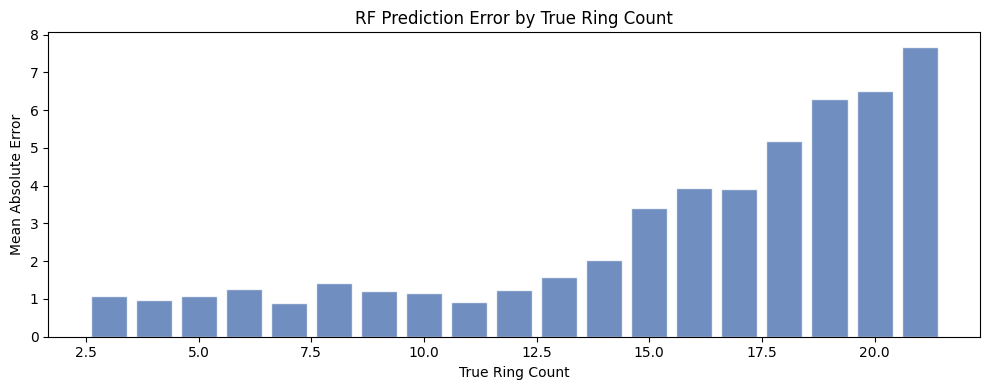

In [48]:
# Since rings is an integer, compare raw RF predictions vs. rounded predictions
y_pred_rf_rounded = np.round(y_pred_rf).astype(int)
y_pred_rf_rounded = np.clip(y_pred_rf_rounded, 1, 29)

rmse_raw     = regression_metrics.rmse(y_test, y_pred_rf)
rmse_rounded = regression_metrics.rmse(y_test, y_pred_rf_rounded)
r2_raw       = regression_metrics.r_squared(y_test, y_pred_rf)
r2_rounded   = regression_metrics.r_squared(y_test, y_pred_rf_rounded)

print(f"Raw continuous predictions  — RMSE: {rmse_raw:.4f}   R²: {r2_raw:.4f}")
print(f"Rounded to nearest integer  — RMSE: {rmse_rounded:.4f}   R²: {r2_rounded:.4f}")
print("\nRounding introduces minimal additional error because rings are already near-integers.")

# Prediction error breakdown by true ring count
fig, ax = plt.subplots(figsize=(10, 4))
ring_vals = sorted(np.unique(y_test.astype(int)))
means, stds = [], []
for rv in ring_vals:
    mask = y_test.astype(int) == rv
    if mask.sum() >= 3:
        err = np.abs(y_pred_rf[mask] - y_test[mask])
        means.append(err.mean()); stds.append(err.std())
    else:
        means.append(np.nan); stds.append(np.nan)

ax.bar(ring_vals, means, color="#4C72B0", edgecolor="white", alpha=0.8)
ax.set_xlabel("True Ring Count"); ax.set_ylabel("Mean Absolute Error")
ax.set_title("RF Prediction Error by True Ring Count")
plt.tight_layout()
plt.show()
